# STEP 11. 2026Q2 예측 산출

드디어 파이프라인의 마지막입니다. **피처 분기 20261 로 20262 를 예측**합니다.

| | 피처 분기 | 타깃 분기 | 라벨 |
|---|---|---|---|
| 학습 | 20231 ~ 20253 | 20232 ~ 20254 | 있음 |
| 검증 | 20254 | 20261 | 있음 |
| **예측** | **20261** | **20262** | **없음 ← 지금 만드는 것** |

## 세 가지를 예측합니다

STEP 10 에서 배운 것 — **순감소는 개업과 폐업의 차이**라 하나로는 부족합니다. 셋을 나란히 냅니다.

| 예측 | 모형 | 뜻 |
|---|---|---|
| **순감소 전환 확률** | STEP 8 부스팅 | 다음 분기에 점포가 순감소로 돌아설 확률 |
| **폐업률** | 음이항 (STEP 10 방식) | 점포 100개당 다음 분기 폐업 건수 |
| **개업률** | 음이항 | 점포 100개당 다음 분기 개업 건수 |

> ⚠️ **"순감소 확률"과 "폐업률"은 다릅니다.** 앞의 것은 규모에 끌려가고(STEP 9-2), 뒤의 것은 그렇지 않습니다. 두 순위가 어긋날 수 있고, 실제로 어긋납니다. 11-4 에서 확인합니다.

## 범위

**골목상권만** 예측합니다. H2·보조질문 2 가 골목상권 대상이었고, 모형도 그 표본으로 학습했기 때문입니다.

자치구 × 업종 표는 만들지 않습니다 — 핵심 질문 담당이 따로 있고, STEP 8 에서 그 단위는 **단일 분기로 검증 불가**(반분 신뢰도 +0.035)임을 확인했습니다. 다만 **칸 단위 예측값은 저장**하므로 필요하면 가져다 쓸 수 있습니다.


In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# config.py 를 고친 뒤 커널을 재시작하지 않으면 파이썬이 옛 모듈을 캐시한다.
import importlib
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import pickle, warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
from config import (PROC, FIG, TARGET_TYPE, TRAIN_QUARTERS, VALID_Q, SCORE_Q,
                    build_features, design_matrix, set_korean_font)
set_korean_font()
warnings.filterwarnings("ignore")
OUT = FIG.parent
SEED, B_BOOT = 42, 500

# ── 원본 적재 (_raw 보존) ───────────────────────
panel_raw  = pd.read_pickle(PROC / "03_panel.pkl")
score_raw  = pd.read_pickle(PROC / "03_score.pkl")
merged_raw = pd.read_pickle(PROC / "02_merged.pkl")
with open(PROC / "08_model.pkl", "rb") as f:
    bundle = pickle.load(f)

print(f"학습·검증 패널 {panel_raw.shape}")
print(f"채점 프레임   {score_raw.shape}  분기 {score_raw['기준_년분기_코드'].unique()}")
print(f"STEP 8 모형   {bundle['model_name']} | 검증 AUC {bundle['valid_metrics']['AUC']:.3f}")

학습·검증 패널 (67475, 36)
채점 프레임   (5428, 34)  분기 [20261]
STEP 8 모형   E 부스팅 | 검증 AUC 0.669


## 11-1. 작업본 준비

STEP 1 과 같은 원칙 — 필요한 범위로 먼저 자른 뒤 `.copy()`.

In [3]:
# 학습용 (골목 · 학습분기) + 다음 분기 개업·폐업 카운트
nx = merged_raw.copy()
nx["분기idx"] = nx["기준_년분기_코드"].map(lambda x: (x // 10) * 4 + (x % 10 - 1))
nx = nx[["상권_코드", "서비스_업종_코드", "분기idx", "개업_점포_수", "폐업_점포_수"]] \
       .rename(columns={"개업_점포_수": "개업_n", "폐업_점포_수": "폐업_n"})

def attach_next(frame):
    f = frame.assign(nxt=frame["분기idx"] + 1)
    return f.merge(nx, left_on=["상권_코드", "서비스_업종_코드", "nxt"],
                   right_on=["상권_코드", "서비스_업종_코드", "분기idx"],
                   how="left", suffixes=("", "_r"), validate="many_to_one")

train = build_features(panel_raw[(panel_raw["상권유형"] == TARGET_TYPE) &
                                 (panel_raw["기준_년분기_코드"].isin(TRAIN_QUARTERS))].copy())
train = attach_next(train)

valid = build_features(panel_raw[(panel_raw["상권유형"] == TARGET_TYPE) &
                                 (panel_raw["기준_년분기_코드"] == VALID_Q)].copy())
valid = attach_next(valid)

score = build_features(score_raw[score_raw["상권유형"] == TARGET_TYPE].copy())

print(f"학습 {len(train):,}행 | 검증 {len(valid):,}행 | 채점 {len(score):,}행")
assert score["기준_년분기_코드"].unique().tolist() == [SCORE_Q]
assert VALID_Q not in train["기준_년분기_코드"].values, "누수: 검증 분기가 학습에 있습니다"
print("✅ 누수 점검 통과")

학습 31,875행 | 검증 2,772행 | 채점 2,737행
✅ 누수 점검 통과


## 11-2. 순감소 전환 확률 — STEP 8 모형

저장해둔 모형을 그대로 불러 채점합니다. 피처는 `config.design_matrix` 로 만들므로 **학습 때와 정확히 같은 방식**입니다.

In [4]:
def p_net(frame):
    X = design_matrix(frame, bundle["columns"])
    if bundle["needs_impute"]:
        X = X.fillna(bundle["median"])
    return bundle["model"].predict_proba(X)[:, 1]

score["p_순감소"] = p_net(score)
valid["p_순감소"] = p_net(valid)
print(f"예측 확률 분포  평균 {score['p_순감소'].mean():.3f} | "
      f"5~95% {score['p_순감소'].quantile(.05):.3f}~{score['p_순감소'].quantile(.95):.3f}")

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


예측 확률 분포  평균 0.231 | 5~95% 0.114~0.390


## 11-3. 개업률·폐업률 — 음이항 모형

STEP 10 방식입니다. 다음 분기 개업·폐업 **건수**를 각각 모형화하고, 오프셋 `log(점포수)` 로 **비율**을 뽑습니다.

**분기 더미는 넣지 않습니다.** 예측 대상 20261 은 학습에 없는 분기라 더미를 만들 수 없기 때문입니다 (STEP 8 과 같은 원칙).

In [5]:
FEA = ["log_점포수", "log_유동인구", "log_면적", "log_집객시설",
       "외식_비중", "프랜차이즈_비율"]

def design_count(f, cols=None):
    X = pd.concat([f[FEA],
                   pd.get_dummies(f["서비스_업종_코드_명"], prefix="svc"),
                   pd.get_dummies(f["자치구"], prefix="gu")], axis=1).astype(float)
    X = sm.add_constant(X, has_constant="add")
    return X if cols is None else X.reindex(columns=cols, fill_value=0.0)

Xt = design_count(train)
CCOLS = list(Xt.columns)
fitted = {}
for yv, nm in [("개업_n", "개업"), ("폐업_n", "폐업")]:
    fitted[nm] = sm.GLM(train[yv], Xt,
                        family=sm.families.NegativeBinomial(alpha=1.0),
                        offset=np.log(train["전체_점포_수"])).fit()

def predict_rates(frame):
    X = design_count(frame, CCOLS)
    off = np.log(frame["전체_점포_수"]).to_numpy()
    out = {}
    for nm, m in fitted.items():
        cnt = m.predict(X, offset=off)
        out[f"예측_{nm}건수"] = cnt
        out[f"예측_{nm}률"] = cnt / frame["전체_점포_수"].to_numpy() * 100   # 점포 100개당
    return pd.DataFrame(out, index=frame.index)

score = score.join(predict_rates(score))
valid = valid.join(predict_rates(valid))
print(f"학습 {len(train):,}행으로 적합 | 피처 {len(CCOLS)}개")
print(f"채점 완료 — 예측 폐업률 평균 {score['예측_폐업률'].mean():.2f}% "
      f"(점포 100개당 {score['예측_폐업률'].mean():.1f}건)")

학습 31,875행으로 적합 | 피처 42개
채점 완료 — 예측 폐업률 평균 4.50% (점포 100개당 4.5건)


## 11-4. 2026Q2 예측 결과 ★

업종별로 집계합니다. **순감소 확률 순위와 폐업률 순위를 나란히** 놓는 게 이 표의 핵심입니다.

In [6]:
def by_svc(f):
    return (f.groupby("서비스_업종_코드_명")
            .agg(칸수=("p_순감소", "size"), 평균점포=("전체_점포_수", "mean"),
                 순감소확률=("p_순감소", "mean"),
                 예측_폐업률=("예측_폐업률", "mean"),
                 예측_개업률=("예측_개업률", "mean"))
            .assign(순증감률=lambda d: d["예측_개업률"] - d["예측_폐업률"]))

pred = by_svc(score)
pred["순감소_순위"] = pred["순감소확률"].rank(ascending=False).astype(int)
pred["폐업률_순위"] = pred["예측_폐업률"].rank(ascending=False).astype(int)
display(pred.sort_values("예측_폐업률", ascending=False).round(2))

rho = spearmanr(pred["순감소확률"], pred["예측_폐업률"]).statistic
print(f"두 순위의 상관 : {rho:+.3f}")
print(f"※ 단위 — 폐업률·개업률은 '점포 100개당 다음 분기 건수', 순감소확률은 '칸이 순감소로 돌아설 확률'")

,칸수,평균점포,순감소확률,예측_폐업률,예측_개업률,순증감률,순감소_순위,폐업률_순위
서비스_업종_코드_명,,,,,,,,
패스트푸드점,104,6.82,0.20,5.55,3.76,-1.80,8,1
치킨전문점,149,6.50,0.20,5.20,3.10,-2.10,7,2
분식전문점,276,8.10,0.21,4.96,3.92,-1.05,5,3
중식음식점,94,9.89,0.21,4.91,4.05,-0.86,6,4
커피-음료,616,12.42,0.24,4.88,4.30,-0.58,2,5
일식음식점,74,8.36,0.20,4.59,3.73,-0.85,9,6
양식음식점,116,11.60,0.24,4.45,3.84,-0.61,3,7
제과점,133,7.47,0.20,4.43,3.37,-1.06,10,8
호프-간이주점,350,11.24,0.23,4.02,2.91,-1.11,4,9


두 순위의 상관 : -0.370
※ 단위 — 폐업률·개업률은 '점포 100개당 다음 분기 건수', 순감소확률은 '칸이 순감소로 돌아설 확률'


### 두 지표가 정반대를 가리킵니다

같은 데이터, 같은 분기, 같은 업종인데 **순위가 뒤집힙니다.** 이건 오류가 아니라 **두 지표가 다른 것을 재기 때문**입니다.

- **순감소 확률** — 규모에 끌려갑니다 (STEP 9-2). 점포가 많은 칸은 뭐라도 일어날 확률이 높아 순감소로 잡히기 쉽습니다
- **폐업률** — 점포 수로 나눈 값이라 규모 영향이 제거됩니다

**정책 판단에는 폐업률을 써야 합니다.** 순감소 확률은 "이 칸이 줄어들까"를 답할 뿐 "여기 가게가 위험한가"를 답하지 않습니다.

In [7]:
cmp = pred[["평균점포", "순감소확률", "순감소_순위", "예측_폐업률", "폐업률_순위"]].copy()
cmp["순위차"] = cmp["순감소_순위"] - cmp["폐업률_순위"]
display(cmp.sort_values("순위차").round(2))
print("※ 순위차가 크게 음수 = 순감소로 보면 위험 상위인데 폐업률로 보면 안전")
print("   가게 수가 많은 업종에서 이 현상이 나타납니다.")

,평균점포,순감소확률,순감소_순위,예측_폐업률,폐업률_순위,순위차
서비스_업종_코드_명,,,,,,
한식음식점,21.30,0.25,1,3.98,10,-9
호프-간이주점,11.24,0.23,4,4.02,9,-5
양식음식점,11.60,0.24,3,4.45,7,-4
커피-음료,12.42,0.24,2,4.88,5,-3
중식음식점,9.89,0.21,6,4.91,4,2
분식전문점,8.10,0.21,5,4.96,3,2
제과점,7.47,0.20,10,4.43,8,2
일식음식점,8.36,0.20,9,4.59,6,3
치킨전문점,6.50,0.20,7,5.20,2,5


※ 순위차가 크게 음수 = 순감소로 보면 위험 상위인데 폐업률로 보면 안전
   가게 수가 많은 업종에서 이 현상이 나타납니다.


## 11-5. 이 예측을 얼마나 믿을 수 있나

**같은 모형으로 20261 을 예측하고 실제와 대조합니다.** 20254 피처 → 20261 타깃이고, 20261 의 실제 개업·폐업은 우리가 갖고 있으므로 채점이 가능합니다.

이게 통과해야 20262 예측을 내놓을 수 있습니다.

In [8]:
chk = (valid.groupby("서비스_업종_코드_명")
       .agg(칸수=("y", "size"),
            예측_순감소=("p_순감소", "mean"), 실제_순감소=("y", "mean"),
            예측_폐업건수=("예측_폐업건수", "mean"), 실제_폐업건수=("폐업_n", "mean"),
            예측_개업건수=("예측_개업건수", "mean"), 실제_개업건수=("개업_n", "mean")))
display(chk.round(3))

r_net  = spearmanr(chk["예측_순감소"], chk["실제_순감소"]).statistic
r_clos = spearmanr(chk["예측_폐업건수"], chk["실제_폐업건수"]).statistic
r_open = spearmanr(chk["예측_개업건수"], chk["실제_개업건수"]).statistic
print(f"업종 순위상관  순감소 {r_net:+.3f} | 폐업 {r_clos:+.3f} | 개업 {r_open:+.3f}")
print(f"평균 절대오차  폐업건수 {abs(chk['예측_폐업건수']-chk['실제_폐업건수']).mean():.3f}건 "
      f"| 개업건수 {abs(chk['예측_개업건수']-chk['실제_개업건수']).mean():.3f}건")
print()
print("※ 순위상관 1.0 = 순위가 완벽히 일치. 0.7 이상이면 업종 줄세우기에 쓸 만합니다.")

,칸수,예측_순감소,실제_순감소,예측_폐업건수,실제_폐업건수,예측_개업건수,실제_개업건수
서비스_업종_코드_명,,,,,,,
분식전문점,287,0.207,0.230,0.403,0.338,0.315,0.209
양식음식점,117,0.238,0.274,0.522,0.581,0.448,0.350
일식음식점,78,0.196,0.231,0.389,0.423,0.318,0.115
제과점,131,0.200,0.229,0.333,0.336,0.256,0.198
중식음식점,93,0.201,0.172,0.500,0.484,0.387,0.505
치킨전문점,145,0.192,0.152,0.343,0.310,0.204,0.234
커피-음료,631,0.236,0.217,0.600,0.512,0.531,0.450
패스트푸드점,106,0.201,0.189,0.385,0.368,0.261,0.189
한식음식점,828,0.254,0.257,0.866,0.772,0.875,0.702


업종 순위상관  순감소 +0.648 | 폐업 +0.915 | 개업 +0.624
평균 절대오차  폐업건수 0.048건 | 개업건수 0.108건

※ 순위상관 1.0 = 순위가 완벽히 일치. 0.7 이상이면 업종 줄세우기에 쓸 만합니다.


### 불확실성 — 업종별 예측의 흔들림 폭

칸을 상권 단위로 복원추출해 업종별 평균 예측을 다시 계산합니다. **표본이 얇은 업종일수록 구간이 넓게** 나옵니다.

In [9]:
rng = np.random.default_rng(SEED)
areas = score["상권_코드"].unique()
pos = {a: np.where(score["상권_코드"].to_numpy() == a)[0] for a in areas}
svc_arr = score["서비스_업종_코드_명"].to_numpy()
rate = score["예측_폐업률"].to_numpy()

boots = []
for _ in range(B_BOOT):
    sel = np.concatenate([pos[a] for a in rng.choice(areas, len(areas), replace=True)])
    boots.append(pd.Series(rate[sel]).groupby(svc_arr[sel]).mean())
bs = pd.DataFrame(boots)

ci = pd.DataFrame({"예측_폐업률": pred["예측_폐업률"],
                   "CI_low": bs.quantile(.025), "CI_high": bs.quantile(.975),
                   "칸수": pred["칸수"]})
ci["구간폭"] = ci["CI_high"] - ci["CI_low"]
display(ci.sort_values("예측_폐업률", ascending=False).round(2))
print(f"부트스트랩 {B_BOOT}회 (상권 {len(areas)}개 복원추출)")
print("※ 구간이 겹치는 업종끼리는 순위 차이를 주장하지 마세요.")

,예측_폐업률,CI_low,CI_high,칸수,구간폭
패스트푸드점,5.55,5.41,5.67,104,0.26
치킨전문점,5.20,5.10,5.29,149,0.19
분식전문점,4.96,4.89,5.03,276,0.14
중식음식점,4.91,4.79,5.02,94,0.23
커피-음료,4.88,4.83,4.93,616,0.10
일식음식점,4.59,4.46,4.72,74,0.26
양식음식점,4.45,4.36,4.54,116,0.17
제과점,4.43,4.34,4.52,133,0.18
호프-간이주점,4.02,3.97,4.07,350,0.10
한식음식점,3.98,3.94,4.01,825,0.08


부트스트랩 500회 (상권 874개 복원추출)
※ 구간이 겹치는 업종끼리는 순위 차이를 주장하지 마세요.


## 11-6. 시각화

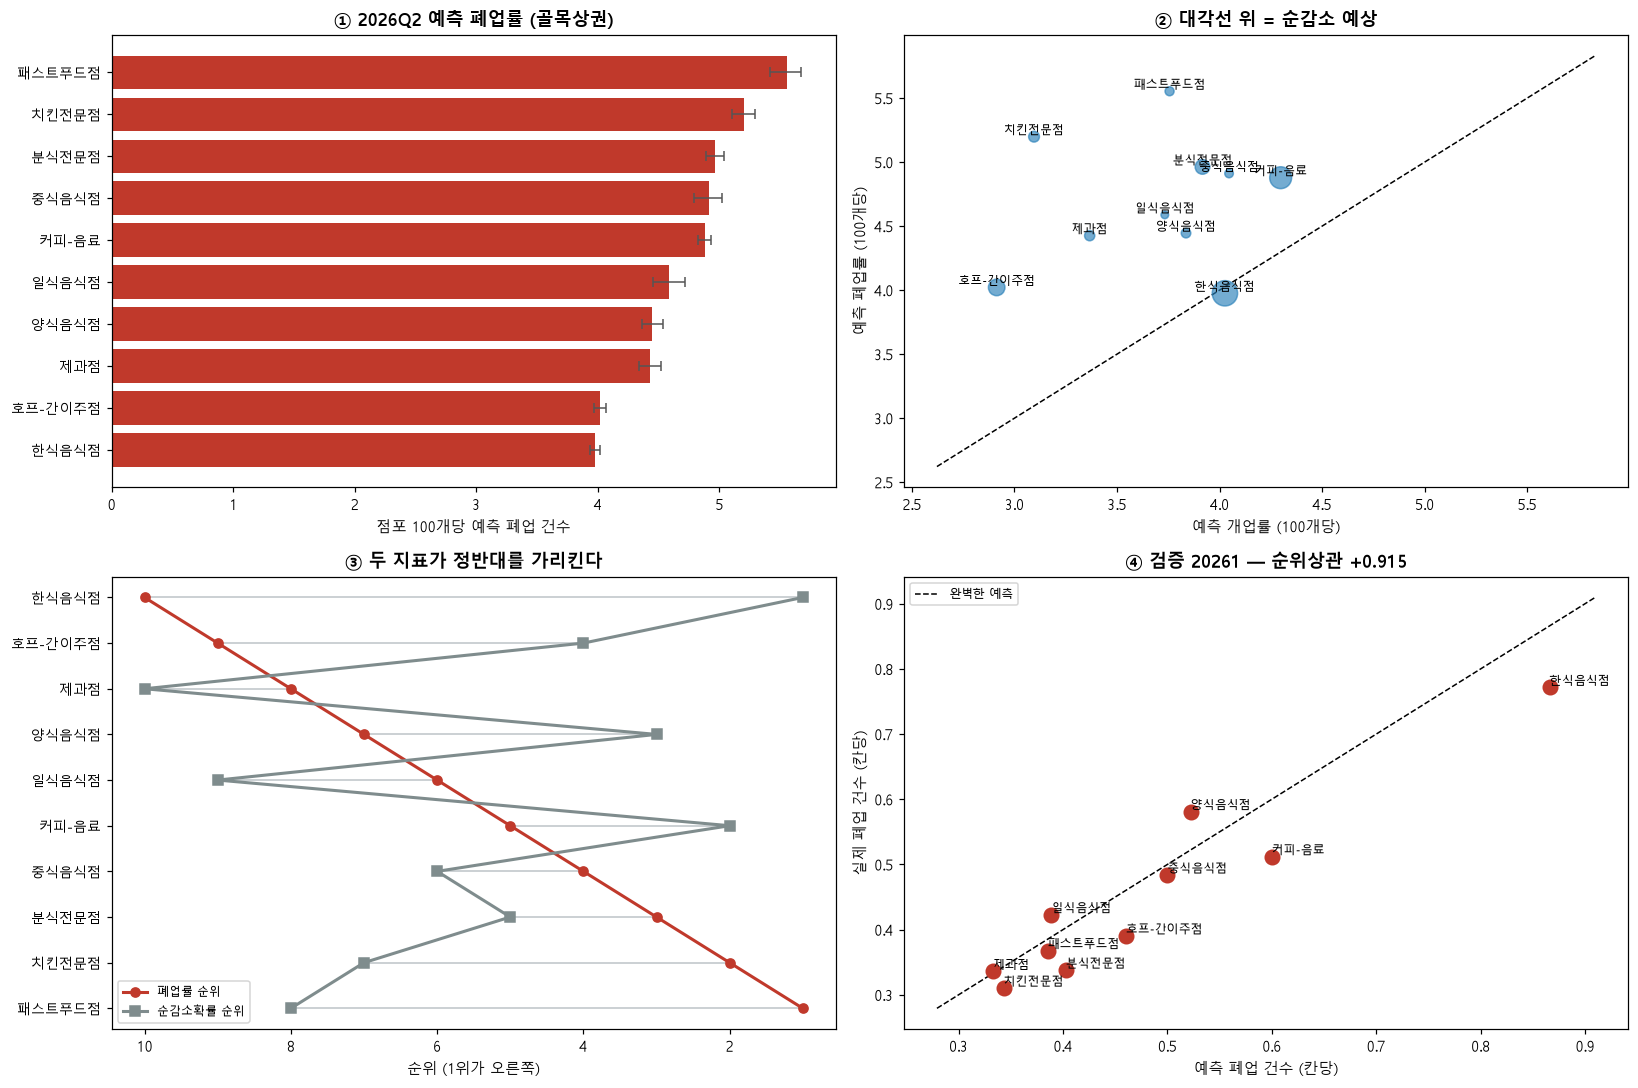

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# ① 폐업률 예측 + 신뢰구간
c = ci.sort_values("예측_폐업률")
y = np.arange(len(c))
ax[0,0].barh(y, c["예측_폐업률"], color="#c0392b",
             xerr=[c["예측_폐업률"]-c["CI_low"], c["CI_high"]-c["예측_폐업률"]],
             error_kw=dict(ecolor="#555", lw=1, capsize=3))
ax[0,0].set_yticks(y); ax[0,0].set_yticklabels(c.index, fontsize=9)
ax[0,0].set_xlabel("점포 100개당 예측 폐업 건수")
ax[0,0].set_title("① 2026Q2 예측 폐업률 (골목상권)", weight="bold")

# ② 개업 vs 폐업
ax[0,1].scatter(pred["예측_개업률"], pred["예측_폐업률"], s=pred["칸수"]/3,
                c="#2980b9", alpha=.65, zorder=3)
lim = [min(pred[["예측_개업률","예측_폐업률"]].min())*.9,
       max(pred[["예측_개업률","예측_폐업률"]].max())*1.05]
ax[0,1].plot(lim, lim, ls="--", c="k", lw=1)
for i, r in pred.iterrows():
    ax[0,1].annotate(i, (r["예측_개업률"], r["예측_폐업률"]), fontsize=8,
                     ha="center", va="bottom")
ax[0,1].set_xlabel("예측 개업률 (100개당)"); ax[0,1].set_ylabel("예측 폐업률 (100개당)")
ax[0,1].set_title("② 대각선 위 = 순감소 예상", weight="bold")

# ③ 두 지표의 순위 어긋남
o = pred.sort_values("예측_폐업률", ascending=False)
yy = np.arange(len(o))
ax[1,0].plot(o["폐업률_순위"], yy, "o-", c="#c0392b", label="폐업률 순위", lw=2)
ax[1,0].plot(o["순감소_순위"], yy, "s-", c="#7f8c8d", label="순감소확률 순위", lw=2)
for k in range(len(o)):
    ax[1,0].plot([o["폐업률_순위"].iloc[k], o["순감소_순위"].iloc[k]], [k, k],
                 c="#bdc3c7", lw=1, zorder=0)
ax[1,0].set_yticks(yy); ax[1,0].set_yticklabels(o.index, fontsize=9)
ax[1,0].invert_xaxis(); ax[1,0].set_xlabel("순위 (1위가 오른쪽)")
ax[1,0].set_title("③ 두 지표가 정반대를 가리킨다", weight="bold")
ax[1,0].legend(fontsize=8)

# ④ 검증 — 예측 vs 실제
ax[1,1].scatter(chk["예측_폐업건수"], chk["실제_폐업건수"], s=90, c="#c0392b", zorder=3)
lo = min(chk[["예측_폐업건수","실제_폐업건수"]].min())*.9
hi = max(chk[["예측_폐업건수","실제_폐업건수"]].max())*1.05
ax[1,1].plot([lo, hi], [lo, hi], ls="--", c="k", lw=1, label="완벽한 예측")
for i, r in chk.iterrows():
    ax[1,1].annotate(i, (r["예측_폐업건수"], r["실제_폐업건수"]), fontsize=8,
                     ha="left", va="bottom")
ax[1,1].set_xlabel("예측 폐업 건수 (칸당)"); ax[1,1].set_ylabel("실제 폐업 건수 (칸당)")
ax[1,1].set_title(f"④ 검증 20261 — 순위상관 {r_clos:+.3f}", weight="bold")
ax[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "step11_forecast.png", dpi=130)
plt.show()

## 11-7. 저장 및 정리

In [11]:
keep = ["기준_년분기_코드", "상권_코드", "상권_코드_명", "자치구", "상권유형",
        "서비스_업종_코드", "서비스_업종_코드_명", "전체_점포_수",
        "p_순감소", "예측_개업건수", "예측_폐업건수", "예측_개업률", "예측_폐업률"]
score[keep].to_pickle(PROC / "11_forecast_2026Q2.pkl")
score[keep].to_csv(OUT / "forecast_2026Q2_cell.csv", index=False, encoding="utf-8-sig")
pred.to_csv(OUT / "forecast_2026Q2_service.csv", encoding="utf-8-sig")
chk.to_csv(OUT / "forecast_validation.csv", encoding="utf-8-sig")
print(f"[저장] 11_forecast_2026Q2.pkl  {score[keep].shape}  ← 칸 단위 예측 (자치구 집계는 여기서)")
print("[저장] outputs/forecast_2026Q2_cell.csv, forecast_2026Q2_service.csv, forecast_validation.csv")
print("[저장] figures/step11_forecast.png\n")

top_c = pred["예측_폐업률"].idxmax(); bot_c = pred["예측_폐업률"].idxmin()
top_n = pred["순감소확률"].idxmax()
print("=" * 64)
print(f"2026Q2 예측 — {TARGET_TYPE} 외식업 {len(score):,}칸")
print("-" * 64)
print(f"  폐업률 최고   {top_c} {pred.loc[top_c,'예측_폐업률']:.2f}% (100개당 {pred.loc[top_c,'예측_폐업률']:.1f}건)")
print(f"  폐업률 최저   {bot_c} {pred.loc[bot_c,'예측_폐업률']:.2f}%")
print(f"  순감소 최고   {top_n} {pred.loc[top_n,'순감소확률']:.1%}  ← 폐업률 순위는 {int(pred.loc[top_n,'폐업률_순위'])}위")
print()
print(f"  검증 순위상관  폐업 {r_clos:+.3f} / 개업 {r_open:+.3f} / 순감소 {r_net:+.3f}")
print()
print("  해석 주의")
print("   · '순감소 확률'은 규모에 끌려갑니다. 정책 판단에는 폐업률을 쓰세요")
print("   · 신뢰구간이 겹치는 업종끼리는 순위 차이를 주장하지 마세요")
print("   · 자치구 × 업종 단위는 검증 불가 구간입니다 (STEP 8 참조)")
print("=" * 64)

[저장] 11_forecast_2026Q2.pkl  (2737, 13)  ← 칸 단위 예측 (자치구 집계는 여기서)
[저장] outputs/forecast_2026Q2_cell.csv, forecast_2026Q2_service.csv, forecast_validation.csv
[저장] figures/step11_forecast.png

2026Q2 예측 — 골목상권 외식업 2,737칸
----------------------------------------------------------------
  폐업률 최고   패스트푸드점 5.55% (100개당 5.6건)
  폐업률 최저   한식음식점 3.98%
  순감소 최고   한식음식점 25.3%  ← 폐업률 순위는 10위

  검증 순위상관  폐업 +0.915 / 개업 +0.624 / 순감소 +0.648

  해석 주의
   · '순감소 확률'은 규모에 끌려갑니다. 정책 판단에는 폐업률을 쓰세요
   · 신뢰구간이 겹치는 업종끼리는 순위 차이를 주장하지 마세요
   · 자치구 × 업종 단위는 검증 불가 구간입니다 (STEP 8 참조)


---

## 이 예측이 프로젝트 결론과 맞아떨어지는 지점

H2 검증에서 얻은 결론은 **"규모를 맞추면 한식이 오히려 안전하다"** 였습니다.

이번 예측이 그것을 독립적으로 재현합니다 — **순감소 확률로 보면 한식이 1위(위험)인데, 규모로 나눈 폐업률로 보면 최하위(안전)** 입니다. 인과 분석(STEP 6·7·9)과 예측(STEP 11)이 서로 다른 경로로 같은 그림에 도달했습니다.

발표에서는 이 두 숫자를 나란히 놓는 게 가장 강력합니다.

## 남은 것

- 자치구 × 업종 집계는 `11_forecast_2026Q2.pkl` 에서 바로 만들 수 있습니다. 다만 **그 단위는 단일 분기 검증이 불가능**하다는 점(STEP 8 8-7)을 함께 전달해야 합니다
- 발달상권·전통시장은 예측하지 않았습니다. 모형이 골목상권으로 학습됐기 때문이며, 필요하면 상권유형별로 다시 학습해야 합니다
